In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, MutableMapping, Tuple
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [47]:
import sys
import os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
from src.align import *
from src.evaluate import *
from src.features import *
from src.process import *
from src.utils import *
from src.vis import *

In [4]:
df = pd.read_csv("outputs/eval_all.csv")
df_CG = df[df['pair_id'].str.contains('CG')]
df_DMR = df[df['pair_id'].str.contains('DMR')]
df_DMC = df[df['pair_id'].str.contains('DMC')]
df_STICKY = df[df['pair_id'].str.contains('STICKY')]

# print("\ndf_CG mean:\n", df_CG.mean(numeric_only=True))
# print("\ndf_DMR mean:\n", df_DMR.mean(numeric_only=True))
# print("\ndf_DMC mean:\n", df_DMC.mean(numeric_only=True))
# print("\ndf_STICKY mean:\n", df_STICKY.mean(numeric_only=True))
means_df = pd.DataFrame({
    'CG': df_CG.mean(numeric_only=True),
    'DMR': df_DMR.mean(numeric_only=True),
    'DMC': df_DMC.mean(numeric_only=True),
    'STICKY': df_STICKY.mean(numeric_only=True)
})
print(means_df)

                                    CG         DMR         DMC      STICKY
sim_soft                    186.268817  187.788711  148.639532  123.373556
sim_hard_source             141.306784  166.800421  143.172753  108.164595
sim_hard_target             132.893560  162.119218  140.239204  104.286737
fo_consistency_soft           0.909478    0.913486    0.721979    0.598252
fo_consistency_hard_source    0.944327    0.839665    0.720465    0.543438
fo_consistency_hard_target    0.940190    0.820040    0.709806    0.525713
topk_recall@3                 0.950026    0.846821    0.770625    0.579690
topk_recall@5                 0.950170    0.847358    0.772347    0.583133
topk_recall@10                0.950448    0.848272    0.773760    0.585945
s3_hard                       0.632701    0.686250    0.607822    0.541511
total_loss                    0.136777    0.105469    0.079098    0.111527
runtime_seconds             136.232199   25.358272   97.521741   57.124590


In [16]:
df1 = pd.read_csv("IsoRankN/napa_eval_outputs/eval_all_1.csv")
df1_CG = df1[df1['pair_id'].str.contains('CG')]
df1_DMR = df1[df1['pair_id'].str.contains('DMR')]
df1_DMC = df1[df1['pair_id'].str.contains('DMC')]
df1_STICKY = df1[df1['pair_id'].str.contains('STICKY')]

means_df1 = pd.DataFrame({
    'CG': df1_CG.mean(numeric_only=True),
    'DMR': df1_DMR.mean(numeric_only=True),
    'DMC': df1_DMC.mean(numeric_only=True),
    'STICKY': df1_STICKY.mean(numeric_only=True)
})
print(means_df1)

                                    CG         DMR         DMC      STICKY
sim_soft                     53.703937   73.548540   74.847611   80.537824
sim_hard_source             184.988310  224.434677  221.556172  220.591169
sim_hard_target             183.085904  226.614720  223.428217  224.643245
fo_consistency_soft           0.069994    0.239653    0.249898    0.279539
fo_consistency_hard_source    0.838795    0.933908    0.934052    0.929245
fo_consistency_hard_target    0.833719    0.910113    0.914524    0.900684
topk_recall@3                 0.916012    0.979553    0.981901    0.979725
topk_recall@5                 0.942520    0.990038    0.990868    0.988638
topk_recall@10                0.977681    0.995787    0.996061    0.993717
s3_hard                       0.342723    0.594458    0.541914    0.480919
total_loss                         NaN         NaN         NaN         NaN
runtime_seconds              32.000000   48.100000   40.700000   37.800000


In [10]:
df2 = pd.read_csv("IsoRankN/napa_eval_outputs/eval_all_2.csv")
df2_CG = df2[df2['pair_id'].str.contains('CG')]
df2_DMR = df2[df2['pair_id'].str.contains('DMR')]
df2_DMC = df2[df2['pair_id'].str.contains('DMC')]
df2_STICKY = df2[df2['pair_id'].str.contains('STICKY')]

means_df2 = pd.DataFrame({
    'CG': df2_CG.mean(numeric_only=True),
    'DMR': df2_DMR.mean(numeric_only=True),
    'DMC': df2_DMC.mean(numeric_only=True),
    'STICKY': df2_STICKY.mean(numeric_only=True)
})
print(means_df2)

                                    CG         DMR         DMC      STICKY
sim_soft                    196.106821  221.261580  217.151715  218.304236
sim_hard_source             155.059496  179.487263  178.480795  185.752794
sim_hard_target             161.294280  197.362257  194.406778  197.087326
fo_consistency_soft           0.779899    0.922606    0.918755    0.924806
fo_consistency_hard_source    0.843820    0.775082    0.780989    0.810319
fo_consistency_hard_target    0.868478    0.843471    0.842071    0.852045
topk_recall@3                 0.864220    0.814139    0.816213    0.838565
topk_recall@5                 0.867023    0.814831    0.816833    0.839903
topk_recall@10                0.868234    0.816131    0.817894    0.843085
s3_hard                       0.376845    0.486553    0.411078    0.456432
total_loss                         NaN         NaN         NaN         NaN
runtime_seconds              32.000000   48.100000   40.700000   37.800000


In [11]:
df3 = pd.read_csv("IsoRankN/napa_eval_outputs/eval_all_3.csv")
df3_CG = df3[df3['pair_id'].str.contains('CG')]
df3_DMR = df3[df3['pair_id'].str.contains('DMR')]
df3_DMC = df3[df3['pair_id'].str.contains('DMC')]
df3_STICKY = df3[df3['pair_id'].str.contains('STICKY')]

means_df3 = pd.DataFrame({
    'CG': df3_CG.mean(numeric_only=True),
    'DMR': df3_DMR.mean(numeric_only=True),
    'DMC': df3_DMC.mean(numeric_only=True),
    'STICKY': df3_STICKY.mean(numeric_only=True)
})
print(means_df3)

                                   CG        DMR        DMC     STICKY
sim_soft                    10.139926   2.525271   5.109611   2.695185
sim_hard_source             34.579334  14.681424  15.720496  12.349217
sim_hard_target             28.913787  14.286720  14.832476  12.614122
fo_consistency_soft          0.004220   0.011232   0.023236   0.011743
fo_consistency_hard_source   0.054483   0.073997   0.076842   0.057500
fo_consistency_hard_target   0.063817   0.071033   0.073147   0.058785
topk_recall@3                0.132985   0.151474   0.199729   0.102073
topk_recall@5                0.197199   0.199897   0.290098   0.129971
topk_recall@10               0.330259   0.276213   0.432843   0.175939
s3_hard                      0.027957   0.193036   0.095310   0.092629
total_loss                        NaN        NaN        NaN        NaN
runtime_seconds             32.600000  48.000000  41.300000  39.300000


In [12]:
df4 = pd.read_csv("IsoRankN/napa_eval_outputs/eval_all_4.csv")
df4_CG = df4[df4['pair_id'].str.contains('CG')]
df4_DMR = df4[df4['pair_id'].str.contains('DMR')]
df4_DMC = df4[df4['pair_id'].str.contains('DMC')]
df4_STICKY = df4[df4['pair_id'].str.contains('STICKY')]

means_df4 = pd.DataFrame({
    'CG': df4_CG.mean(numeric_only=True),
    'DMR': df4_DMR.mean(numeric_only=True),
    'DMC': df4_DMC.mean(numeric_only=True),
    'STICKY': df4_STICKY.mean(numeric_only=True)
})
print(means_df4)

                                   CG        DMR        DMC     STICKY
sim_soft                    73.301590  81.979840  73.659525  79.785535
sim_hard_source             34.443584  25.012425  31.218463  13.667519
sim_hard_target             33.365789  27.160480  34.744639  15.077511
fo_consistency_soft          0.339636   0.395910   0.351703   0.369076
fo_consistency_hard_source   0.219708   0.125300   0.154637   0.064742
fo_consistency_hard_target   0.223418   0.135908   0.172165   0.072366
topk_recall@3                0.240151   0.141433   0.176714   0.081098
topk_recall@5                0.242844   0.144577   0.180726   0.086457
topk_recall@10               0.245507   0.150211   0.186455   0.098102
s3_hard                      0.097950   0.074452   0.071178   0.051901
total_loss                        NaN        NaN        NaN        NaN
runtime_seconds             32.600000  48.000000  41.300000  39.300000


- sim_mat: SIM=236.1345, FO_cons=0.9775, 0.9353, 0.9479, Top- FO recall=0.9492, 0.9494, 0.9494, S3_hard=0.4744, S3_soft=0.0000

In [24]:
" & ".join(str(i) for i in [round(x, 4) for x in list(df1_DMR.mean(numeric_only=True))])

'73.5485 & 224.4347 & 226.6147 & 0.2397 & 0.9339 & 0.9101 & 0.9796 & 0.99 & 0.9958 & 0.5945 & nan & 48.1'

#### test

In [30]:
category = "CG"
TIME = "20260104_103800"
# category = "STICKY"
# TIME = "20260104_140536"
import src.evaluate as eval
family = load_family_data(Path(f"data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/{category}/family1"))
sim_mat = eval._similarity_matrix_from_file(f"data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/{category}/family1/A-B.sim", 
source_nodes=list(family.graphs["A"].nodes()), target_nodes=list(family.graphs["B"].nodes()))

2026-01-12 14:26:47,225 | INFO | src.process | Loaded A (3000 nodes, 11987 edges)
2026-01-12 14:26:47,282 | INFO | src.process | Loaded B (4000 nodes, 15987 edges)
2026-01-12 14:26:47,291 | INFO | src.process | Loaded A annotations (2195 nodes with FO labels)
2026-01-12 14:26:47,293 | INFO | src.process | Loaded B annotations (2190 nodes with FO labels)
2026-01-12 14:26:47,815 | INFO | src.process | Loaded similarity file A-B (62342 pairs)


In [48]:
feature_path = f"outputs/2way/{category}/family1/A_vs_B/{TIME}"
output_dir = "/home/bcl/wanghongyu/other/networkscience/outputs"
align_config = AlignmentConfig(
    alpha=0.9,
    rho=0.1,
    eps=1e-8,
    solver="sinkhorn",
    solver_params={"nits_bcd": 100, "nits_uot": 1000, "tol_bcd": 1e-4, "tol_uot": 1e-10},
    device="cuda",
    verbose=True
)
result = fugw_align(family.graphs["A"], family.graphs["B"], 
feature_path=feature_path, 
align_config=align_config, 
output_dir=output_dir,
sim_mat = sim_mat,
use_unit_weights=False)

source_nodes = result['source_nodes']
target_nodes = result['target_nodes']
pi = result["pi"].numpy() / result["pi"].numpy().sum()

2026-01-12 15:13:42,109 | INFO | src.align | Loaded cached features from outputs/2way/CG/family1/A_vs_B/20260104_103800
2026-01-12 15:13:42,110 | INFO | src.align | Source features: (3000, 5), Target features: (4000, 5)
2026-01-12 15:13:42,111 | INFO | src.align | Source geometry: (3000, 3000), Target geometry: (4000, 4000)


Using cost matrix


[15:13:44] Validation data for feature maps is not provided. Using training data instead.              ]8;id=480313;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py\dense.py]8;;\:]8;id=671228;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py#204\204]8;;\

           Validation data for anatomical kernels is not provided. Using training data instead.        ]8;id=728990;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py\dense.py]8;;\:]8;id=440781;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py#231\231]8;;\

Output()

...

Output()

[15:20:18] BCD step 47/100 FUGW loss:      0.20000001788139343     Validation loss:                    ]8;id=657089;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py\dense.py]8;;\:]8;id=946280;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py#521\521]8;;\
           0.20000001788139343                                                                                     

Output()

Output()

[15:20:29] BCD step 48/100 FUGW loss:      0.20000001788139343     Validation loss:                    ]8;id=883216;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py\dense.py]8;;\:]8;id=893920;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py#521\521]8;;\
           0.20000001788139343                                                                                     

In [50]:
sim_path = Path(f"data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/{category}/family1/A-B.sim")

pi_hard1 = np.zeros_like(pi)
row_max_indices = np.argmax(pi, axis=1)
pi_hard1[np.arange(pi.shape[0]), row_max_indices] = 1
pi_hard1 = pi_hard1 / pi_hard1.sum()

pi_hard2 = np.zeros_like(pi)
col_max_indices = np.argmax(pi, axis=0)
pi_hard2[col_max_indices, np.arange(pi.shape[1])] = 1
pi_hard2 = pi_hard2 / pi_hard2.sum()

similarity_score = sim_score(sim_path=sim_path, 
coupling=pi,
source_nodes=source_nodes,
target_nodes=target_nodes)

similarity_score_hard1 = sim_score(sim_path=sim_path, 
coupling=pi_hard1,
source_nodes=source_nodes,
target_nodes=target_nodes)

similarity_score_hard2 = sim_score(sim_path=sim_path, 
coupling=pi_hard2,
source_nodes=source_nodes,
target_nodes=target_nodes)

FO_con_soft_score = FO_con_soft(coupling=pi,
source_nodes=source_nodes,
target_nodes=target_nodes,
source_annotations=family.annotations["A"],
target_annotations=family.annotations["B"]
)

FO_con_hard_score1 = FO_con_hard(coupling=pi,
source_nodes=source_nodes,
target_nodes=target_nodes,
source_annotations=family.annotations["A"],
target_annotations=family.annotations["B"],
axis="source"
)

FO_con_hard_score2 = FO_con_hard(coupling=pi,
source_nodes=source_nodes,
target_nodes=target_nodes,
source_annotations=family.annotations["A"],
target_annotations=family.annotations["B"],
axis="target"
)

topk_recall3 = topk_FO_recall(
    pi,
    source_nodes,
    target_nodes,
    family.annotations["A"],
    family.annotations["B"],
    k=3,
)

topk_recall5 = topk_FO_recall(
    pi,
    source_nodes,
    target_nodes,
    family.annotations["A"],
    family.annotations["B"],
    k=5,
)

topk_recall10 = topk_FO_recall(
    pi,
    source_nodes,
    target_nodes,
    family.annotations["A"],
    family.annotations["B"],
    k=10,
)

# Structural metrics
s3_h = S3_hard(family.graphs["A"], family.graphs["B"], pi, source_nodes, target_nodes)
# s3_s = S3_soft(family.graphs["A"], family.graphs["B"], pi, source_nodes, target_nodes)
s3_s=0

print(
    f"SIM={similarity_score:.4f}, {similarity_score_hard1:.4f}, {similarity_score_hard2:.4f}, FO_cons={FO_con_soft_score:.4f}, {FO_con_hard_score1:.4f}, {FO_con_hard_score2:.4f}, "
    f"Top- FO recall={topk_recall3:.4f}, {topk_recall5:.4f}, {topk_recall10:.4f}, S3_hard={s3_h:.4f}, S3_soft={s3_s:.4f}"
)

SIM=196.2695, 119.7456, 104.1047, FO_cons=0.5881, 0.6419, 0.5626, Top- FO recall=0.6641, 0.6684, 0.6698, S3_hard=0.1365, S3_soft=0.0000


#### Ablation
- benchmark: SIM=236.1345, 151.1847, 111.1828, FO_cons=0.9775, 0.9353, 0.9479, Top-FO recall=0.9492, 0.9494, 0.9494, S3_hard=0.4744, S3_soft=0.0000
- alpha=1: SIM=82.4914, 1.8750, 1.4963, FO_cons=0.0002, 0.0064, 0.0073, Top- FO recall=0.0125, 0.0146, 0.0164, S3_hard=0.0537, S3_soft=0.0000
- alpha=0: SIM=104.3123, 179.1682, 150.7825, FO_cons=0.0692, 0.7376, 0.6982, Top- FO recall=0.8545, 0.8899, 0.9460, S3_hard=0.1802, S3_soft=0.0000
- rho=100: SIM=90.4126, 101.5686, 74.9618, FO_cons=0.3281, 0.6096, 0.6201, Top- FO recall=0.7952, 0.8025, 0.8032, S3_hard=0.2648, S3_soft=0.0000
- rho=0.01: SIM=nan, 0.3067, 1.2423, FO_cons=nan, 0.0005, 0.0005, Top- FO recall=0.0014, 0.0027, 0.0050, S3_hard=0.0000, S3_soft=0.0000
- eps=1e-8: SIM=196.2695, 119.7456, 104.1047, FO_cons=0.5881, 0.6419, 0.5626, Top- FO recall=0.6641, 0.6684, 0.6698, S3_hard=0.1365, S3_soft=0.0000

#### CG
- no sim_mat: SIM=193.5201, FO_cons=0.9381, 0.8292, 0.8306, Top- FO recall=0.8477, 0.8486, 0.8486, S3_hard=0.4054, S3_soft=0.0000
- sim_mat: SIM=236.1345, FO_cons=0.9775, 0.9353, 0.9479, Top- FO recall=0.9492, 0.9494, 0.9494, S3_hard=0.4744, S3_soft=0.0000
- sim_mat and unit weights: SIM=204.0620, FO_cons=0.9785, 0.9349, 0.9447, Top- FO recall=0.9464, 0.9464, 0.9464, S3_hard=0.4751, S3_soft=0.0000

#### STYCKY
- benchmark: SIM=52.2978, FO_cons=0.3466, 0.3268, 0.2747, Top- FO recall=0.3556, 0.3594, 0.3621, S3_hard=0.3073, S3_soft=0.0000
- rho=1: SIM=37.4984, FO_cons=0.2375, 0.2768, 0.2396, Top- FO recall=0.3036, 0.3097, 0.3148, S3_hard=0.3018, S3_soft=0.0000
- sim_mat: SIM=198.6956, FO_cons=0.6809, 0.7149, 0.5949, Top- FO recall=0.7116, 0.7149, 0.7167, S3_hard=0.3817, S3_soft=0.0000
- rho=1：SIM=144.6792, FO_cons=0.4574, 0.6170, 0.4758, Top- FO recall=0.6501, 0.6572, 0.6604, S3_hard=0.3127, S3_soft=0.0000

#### DMR
- sim_mat and unit weights: SIM=191.7362, 176.2222, 163.3198, FO_cons=0.9253, 0.8786, 0.8437, Top- FO recall=0.8792, 0.8795, 0.8802, S3_hard=0.7100, S3_soft=0.0000

#### DMC

#### Tasks
- 测试输入sim_mat但使用均匀分布进行对齐
- 计算最优传输方案的熵

In [27]:
from src.utils import (
    load_cached_features,
    METADATA_FILE,
    PARAMS_FILE,
    RESULTS_FILE,
    SOURCE_FEATURE_FILE,
    TARGET_FEATURE_FILE,
    SOURCE_GEOMETRY_FILE,
    TARGET_GEOMETRY_FILE,
    COUPLING_FILE,
)

run_dir = Path("outputs/20260110_160242")

# Option 1: high-level loader (returns AlignmentCache)
cache = load_cached_features(run_dir)
if cache:
    print("Feature tensor shape:", cache.source_features.shape)

# Option 2: manual access
metadata = json.loads((run_dir / METADATA_FILE).read_text(encoding="utf-8"))
params = json.loads((run_dir / PARAMS_FILE).read_text(encoding="utf-8"))
result = json.loads((run_dir / RESULTS_FILE).read_text(encoding="utf-8"))
source_nodes = metadata['source_nodes']
target_nodes = metadata['target_nodes']

source_features = torch.load(run_dir / SOURCE_FEATURE_FILE, map_location="cpu")
target_features = torch.load(run_dir / TARGET_FEATURE_FILE, map_location="cpu")
feature_mat = (source_features.unsqueeze(1) - target_features.unsqueeze(0)).square().sum(dim=-1)
print(feature_mat.shape)
source_geometry = torch.load(run_dir / SOURCE_GEOMETRY_FILE, map_location="cpu")
target_geometry = torch.load(run_dir / TARGET_GEOMETRY_FILE, map_location="cpu")
coupling = torch.load(run_dir / COUPLING_FILE, map_location="cpu")
pi = coupling.clone() / coupling.sum()
pi = pi.cpu().numpy()

Feature tensor shape: torch.Size([3000, 5])
torch.Size([3000, 4000])


done


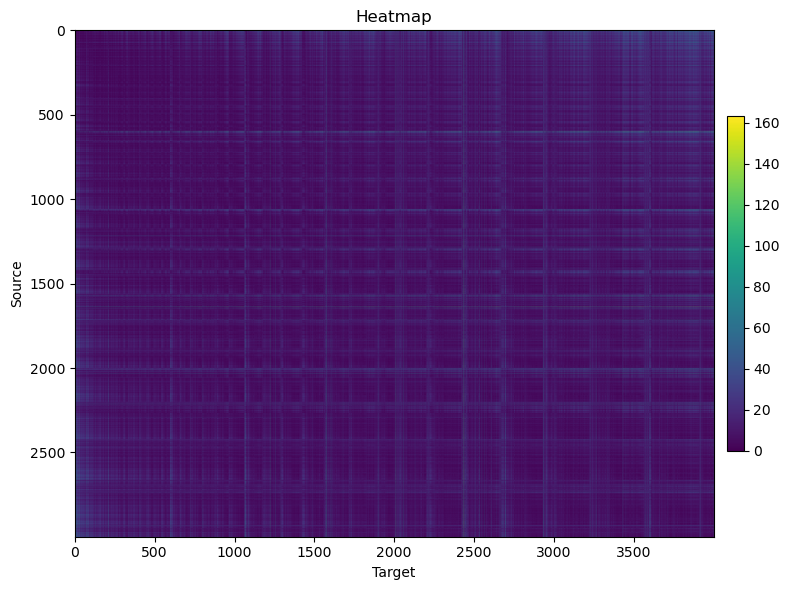

In [29]:
plot_heatmap(feature_mat)
print("done")

In [31]:
# 对于每行/每列只保留最大值的位置，其余为零，然后归一化
pi_hard1 = np.zeros_like(pi)
row_max_indices = np.argmax(pi, axis=1)
pi_hard1[np.arange(pi.shape[0]), row_max_indices] = 1
pi_hard1 = pi_hard1 / pi_hard1.sum()

pi_hard2 = np.zeros_like(pi)
col_max_indices = np.argmax(pi, axis=0)
pi_hard2[col_max_indices, np.arange(pi.shape[1])] = 1
pi_hard2 = pi_hard2 / pi_hard2.sum()

In [32]:
sim_path = Path(f"/home/bcl/wanghongyu/other/networkscience/data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/{category}/family1/A-B.sim")

similarity_score = sim_score(sim_path=sim_path, 
coupling=pi,
source_nodes=source_nodes,
target_nodes=target_nodes)

similarity_score_hard1 = sim_score(sim_path=sim_path, 
coupling=pi_hard1,
source_nodes=source_nodes,
target_nodes=target_nodes)

similarity_score_hard2 = sim_score(sim_path=sim_path, 
coupling=pi_hard2,
source_nodes=source_nodes,
target_nodes=target_nodes)

FO_con_soft_score = FO_con_soft(coupling=pi,
source_nodes=source_nodes,
target_nodes=target_nodes,
source_annotations=family.annotations["A"],
target_annotations=family.annotations["B"]
)

FO_con_hard_score1 = FO_con_hard(coupling=pi,
source_nodes=source_nodes,
target_nodes=target_nodes,
source_annotations=family.annotations["A"],
target_annotations=family.annotations["B"],
axis="source"
)

FO_con_hard_score2 = FO_con_hard(coupling=pi,
source_nodes=source_nodes,
target_nodes=target_nodes,
source_annotations=family.annotations["A"],
target_annotations=family.annotations["B"],
axis="target"
)

topk_recall3 = topk_FO_recall(
    pi,
    source_nodes,
    target_nodes,
    family.annotations["A"],
    family.annotations["B"],
    k=3,
)

topk_recall5 = topk_FO_recall(
    pi,
    source_nodes,
    target_nodes,
    family.annotations["A"],
    family.annotations["B"],
    k=5,
)

topk_recall10 = topk_FO_recall(
    pi,
    source_nodes,
    target_nodes,
    family.annotations["A"],
    family.annotations["B"],
    k=10,
)

# Structural metrics
s3_h = S3_hard(family.graphs["A"], family.graphs["B"], pi, source_nodes, target_nodes)
# s3_s = S3_soft(family.graphs["A"], family.graphs["B"], pi, source_nodes, target_nodes)
s3_s=0

print(
    f"SIM={similarity_score:.4f}, {similarity_score_hard1:.4f}, {similarity_score_hard2:.4f}, FO_cons={FO_con_soft_score:.4f}, {FO_con_hard_score1:.4f}, {FO_con_hard_score2:.4f}, "
    f"Top- FO recall={topk_recall3:.4f}, {topk_recall5:.4f}, {topk_recall10:.4f}, S3_hard={s3_h:.4f}, S3_soft={s3_s:.4f}"
)

SIM=236.1345, 151.1847, 111.1828, FO_cons=0.9775, 0.9353, 0.9479, Top- FO recall=0.9492, 0.9494, 0.9494, S3_hard=0.4744, S3_soft=0.0000
